<a href="https://colab.research.google.com/github/edwinorthiz/Mi-Portafolio/blob/main/Caso_EDA_colesterol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

En el siguiente ejercicio exploraremos los datos de pacientes asociados al nivel de colesterol según la edad, sexo, peso y estatura.

¿Qué es el colesterol?
segun el sitio: https://medlineplus.gov/spanish/cholesterol.html#:~:text=%C2%BFQu%C3%A9%20es%20el%20colesterol%3F,todo%20el%20colesterol%20que%20necesita.
El colesterol es una sustancia cerosa y parecida a la grasa que se encuentra en todas las células de su cuerpo. Su cuerpo necesita algo de colesterol para producir hormonas, vitamina D y sustancias que le ayuden a digerir los alimentos. Su cuerpo produce todo el colesterol que necesita.

segun el sitio: https://medlineplus.gov/spanish/ldlthebadcholesterol.html
¿Cuál debería ser mi nivel de colesterol malo (LDL)?
Tener números bajos de colesterol malo (LDL) son buenos, porque un nivel alto de LDL puede aumentar el riesgo de enfermedad de las arterias coronarias y problemas relacionados. Los rangos generales para adultos sanos son:
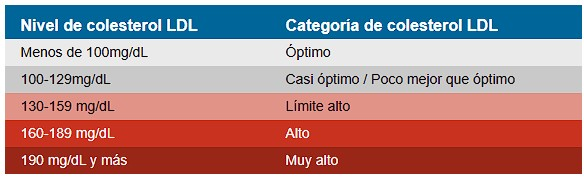



In [56]:
#Leer fuente de datos y visualizarla
import pandas as pd
df = pd.read_csv('colesterol.csv', thousands=',')
df = df.applymap(lambda x: x.replace('.', ',') if isinstance(x, str) else x)
df

<ipython-input-56-581f21ef829a>:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.replace('.', ',') if isinstance(x, str) else x)


,nombre,edad,sexo,peso,altura,colesterol
0,José Luis Martínez Izquierdo,18,H,85.0,1.79,182.0
1,Rosa Díaz Díaz,32,M,65.0,1.73,232.0
2,Javier García Sánchez,24,H,NaN,1.81,191.0
3,Carmen López Pinzón,35,M,65.0,1.70,200.0
4,Marisa López Collado,46,M,51.0,1.58,148.0
5,Antonio Ruiz Cruz,68,H,66.0,1.74,249.0
6,Antonio Fernández Ocaña,51,H,62.0,1.72,276.0
7,Pilar Martín González,22,M,60.0,1.66,NaN
8,Pedro Gálvez Tenorio,35,H,90.0,1.94,241.0
9,Santiago Reillo Manzano,46,H,75.0,1.85,280.0


In [57]:
#Visualizar información de las columnas del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   nombre      14 non-null     object 
 1   edad        14 non-null     int64  
 2   sexo        14 non-null     object 
 3   peso        13 non-null     float64
 4   altura      14 non-null     float64
 5   colesterol  13 non-null     float64
dtypes: float64(3), int64(1), object(2)
memory usage: 804.0+ bytes


In [58]:
#Visualizar la Cantidad de Registros del DataFrame
df.count()

,0
nombre,14
edad,14
sexo,14
peso,13
altura,14
colesterol,13


In [59]:
#Visualizar la cantidad de valores nulo del DataFrame
df.isnull().sum()

,0
nombre,0
edad,0
sexo,0
peso,1
altura,0
colesterol,1


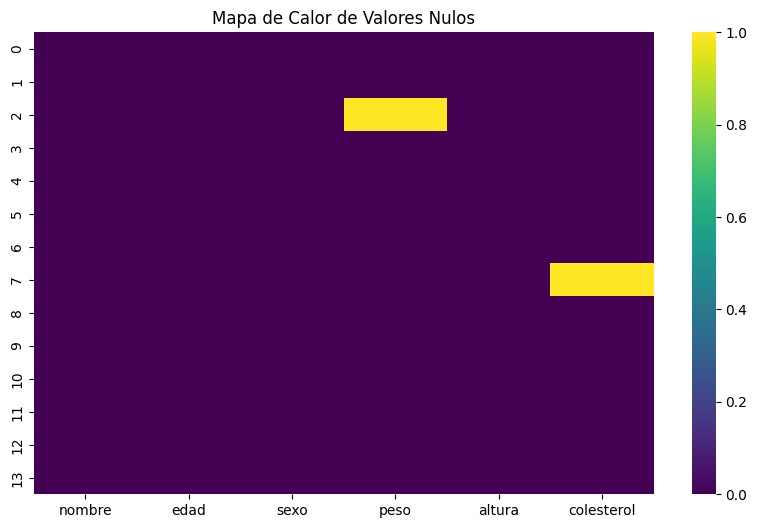

In [60]:
#Crear mapa de calor para ver datos Nulos
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis')
plt.title('Mapa de Calor de Valores Nulos')
plt.show()

In [61]:
#Imputar el valores nulo con la media
valores_por_media = {
    'colesterol': round(df['colesterol'].mean(), 2),
    'peso': round(df['peso'].mean(), 2)
}

df.fillna(valores_por_media, inplace=True)
df


,nombre,edad,sexo,peso,altura,colesterol
0,José Luis Martínez Izquierdo,18,H,85.00,1.79,182.00
1,Rosa Díaz Díaz,32,M,65.00,1.73,232.00
2,Javier García Sánchez,24,H,70.92,1.81,191.00
3,Carmen López Pinzón,35,M,65.00,1.70,200.00
4,Marisa López Collado,46,M,51.00,1.58,148.00
5,Antonio Ruiz Cruz,68,H,66.00,1.74,249.00
6,Antonio Fernández Ocaña,51,H,62.00,1.72,276.00
7,Pilar Martín González,22,M,60.00,1.66,220.23
8,Pedro Gálvez Tenorio,35,H,90.00,1.94,241.00
9,Santiago Reillo Manzano,46,H,75.00,1.85,280.00


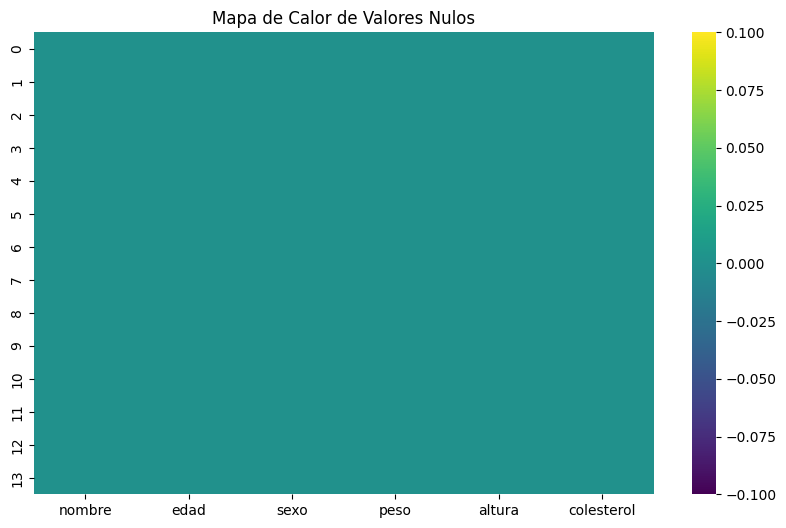

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis')
plt.title('Mapa de Calor de Valores Nulos')
plt.show()

In [63]:
#Realizar limpieza de datos
df.dropna(inplace=True)
df


,nombre,edad,sexo,peso,altura,colesterol
0,José Luis Martínez Izquierdo,18,H,85.00,1.79,182.00
1,Rosa Díaz Díaz,32,M,65.00,1.73,232.00
2,Javier García Sánchez,24,H,70.92,1.81,191.00
3,Carmen López Pinzón,35,M,65.00,1.70,200.00
4,Marisa López Collado,46,M,51.00,1.58,148.00
5,Antonio Ruiz Cruz,68,H,66.00,1.74,249.00
6,Antonio Fernández Ocaña,51,H,62.00,1.72,276.00
7,Pilar Martín González,22,M,60.00,1.66,220.23
8,Pedro Gálvez Tenorio,35,H,90.00,1.94,241.00
9,Santiago Reillo Manzano,46,H,75.00,1.85,280.00


In [64]:
#Convertir los datos object a String
df['nombre'] = df['nombre'].astype('string')
df['sexo'] = df['sexo'].astype('string')

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   nombre      14 non-null     string 
 1   edad        14 non-null     int64  
 2   sexo        14 non-null     string 
 3   peso        14 non-null     float64
 4   altura      14 non-null     float64
 5   colesterol  14 non-null     float64
dtypes: float64(3), int64(1), string(2)
memory usage: 804.0 bytes


In [66]:
#Convertir los datos String a mayúsculas
df['nombre'] = df['nombre'].str.upper()
#Convertir los datos String a mayúsculas
df['sexo'] = df['sexo'].str.upper()
df

,nombre,edad,sexo,peso,altura,colesterol
0,JOSÉ LUIS MARTÍNEZ IZQUIERDO,18,H,85.00,1.79,182.00
1,ROSA DÍAZ DÍAZ,32,M,65.00,1.73,232.00
2,JAVIER GARCÍA SÁNCHEZ,24,H,70.92,1.81,191.00
3,CARMEN LÓPEZ PINZÓN,35,M,65.00,1.70,200.00
4,MARISA LÓPEZ COLLADO,46,M,51.00,1.58,148.00
5,ANTONIO RUIZ CRUZ,68,H,66.00,1.74,249.00
6,ANTONIO FERNÁNDEZ OCAÑA,51,H,62.00,1.72,276.00
7,PILAR MARTÍN GONZÁLEZ,22,M,60.00,1.66,220.23
8,PEDRO GÁLVEZ TENORIO,35,H,90.00,1.94,241.00
9,SANTIAGO REILLO MANZANO,46,H,75.00,1.85,280.00


In [67]:
#Generar la Estadística Descriptiva (Medidas)
df.describe()

,edad,peso,altura,colesterol
count,14.000000,14.000000,14.000000,14.000000
mean,38.214286,70.922857,1.768571,220.230714
std,15.621379,15.494225,0.115016,38.284670
min,18.000000,51.000000,1.580000,148.000000
25%,24.750000,61.250000,1.705000,195.000000
50%,35.000000,65.500000,1.755000,215.115000
75%,49.750000,77.250000,1.840000,247.000000
max,68.000000,109.000000,1.980000,280.000000


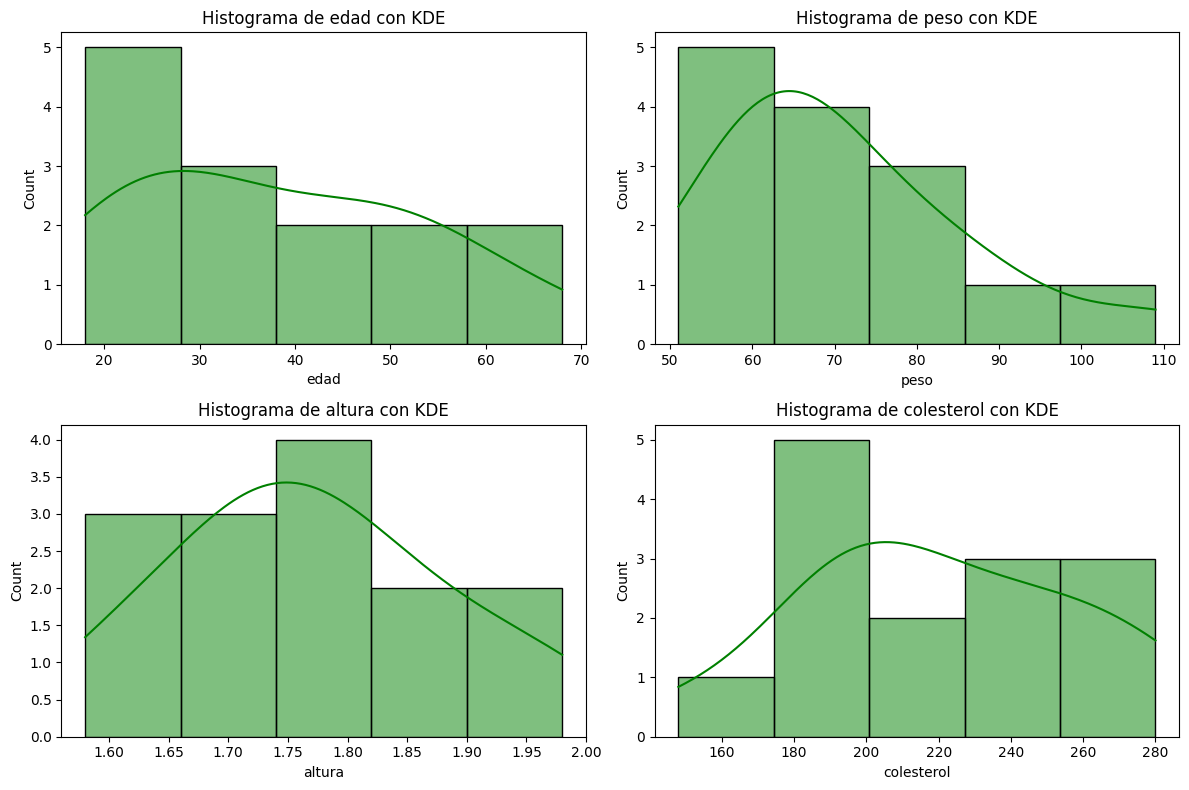

In [70]:
#Histograma de Frecuencias para la edad, peso, altura y colesterol indicando simetría o sesgo
import seaborn as sns
import matplotlib.pyplot as plt

columnas = ['edad', 'peso', 'altura', 'colesterol']

plt.figure(figsize=(12, 8))
for i, col in enumerate(columnas, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=df, x=col, bins=5, kde=True, color='green')
    plt.title(f'Histograma de {col} con KDE')

plt.tight_layout()
plt.show()



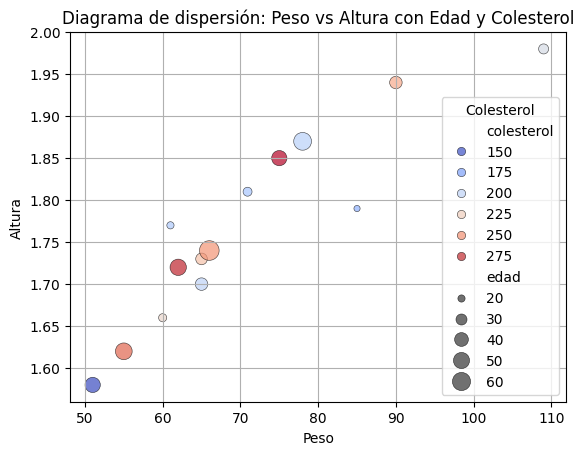

In [82]:
#Diagrama de dispersión con media y desviación estándar para edad, peso, altura y colesterol


# Diagrama de dispersión:
# Eje x: peso
# Eje y: altura
# Color: colesterol
# Tamaño: edad

sns.scatterplot(
    data=df,
    x='peso',
    y='altura',
    hue='colesterol',   # color según nivel de colesterol
    size='edad',        # tamaño según edad
    palette='coolwarm',
    sizes=(20, 200),
    alpha=0.7,
    edgecolor='k'
)

plt.title('Diagrama de dispersión: Peso vs Altura con Edad y Colesterol')
plt.xlabel('Peso')
plt.ylabel('Altura')
plt.legend(title='Colesterol')
plt.grid(True)
plt.show()


<ipython-input-81-16916786b023>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='variable', y='valor', data=df_melt, palette='pastel')


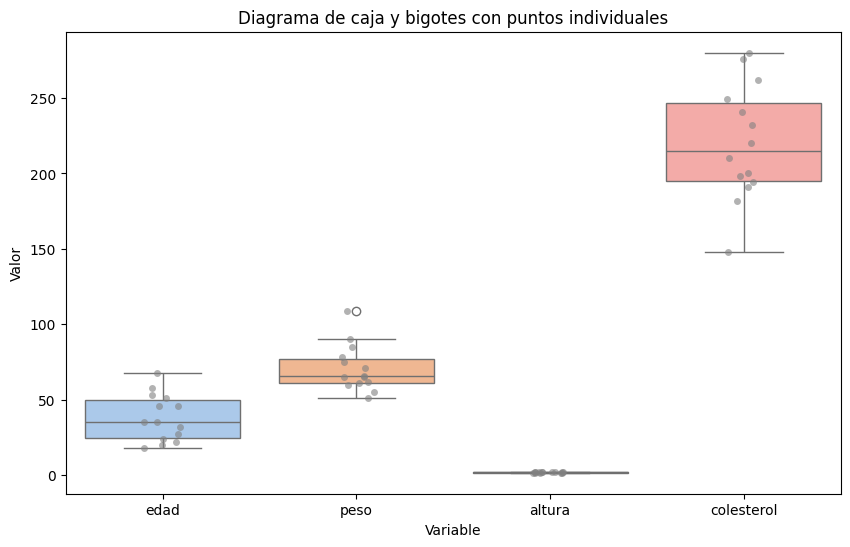

In [81]:
#Diagrama de Caja y bigotes con datos (puntos) para edad, peso, altura y colesterol


# Primero, "derretimos" el DataFrame para pasar de formato ancho a largo
df_melt = df.melt(value_vars=['edad', 'peso', 'altura', 'colesterol'], var_name='variable', value_name='valor')

plt.figure(figsize=(10,6))

# Boxplot
sns.boxplot(x='variable', y='valor', data=df_melt, palette='pastel')

# Agregar puntos individuales para mostrar distribución (usar jitter para separar puntos)
sns.stripplot(x='variable', y='valor', data=df_melt, color='gray', alpha=0.6, jitter=True)

plt.title('Diagrama de caja y bigotes con puntos individuales')
plt.xlabel('Variable')
plt.ylabel('Valor')
plt.show()


                edad      peso    altura  colesterol
edad        1.000000 -0.266531 -0.181774    0.431733
peso       -0.266531  1.000000  0.914027    0.000005
altura     -0.181774  0.914027  1.000000    0.118080
colesterol  0.431733  0.000005  0.118080    1.000000


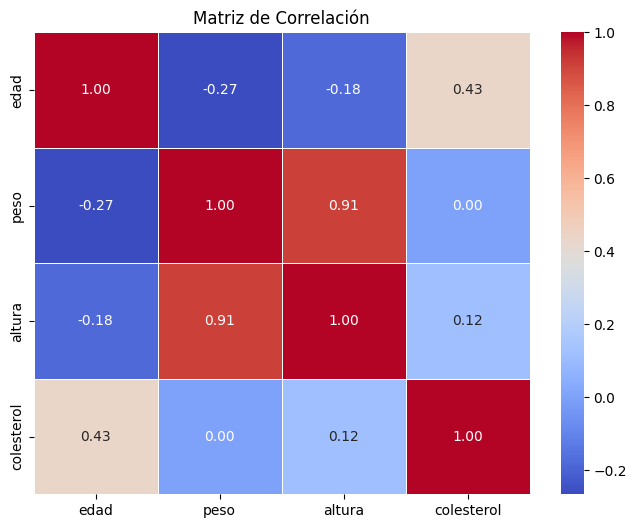

In [80]:
#Matriz de Correlación para el DataFrame

# Columnas específicas:
cols = ['edad', 'peso', 'altura', 'colesterol']

# Calculamos la matriz de correlación solo para esas columnas
corr_matrix = df[cols].corr()

# Imprimir la matriz de correlación
print(corr_matrix)

# Graficar con seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()



In [84]:
#Realizar la transformación: Promedio de peso y edad por sexo
promedios_por_sexo = df.groupby('sexo')[['peso', 'edad']].mean()

print(promedios_por_sexo)

       peso       edad
sexo                  
H     79.49  40.875000
M     59.50  34.666667


In [86]:
#Realizar la transformación: Máximo y promedio de colesterol para ROSA DÍAZ DÍAZ, CARMEN LÓPEZ PINZÓN y CAROLINA RUBIO MORENO
# Lista de nombres
nombres = ['ROSA DÍAZ DÍAZ', 'CARMEN LÓPEZ PINZÓN', 'CAROLINA RUBIO MORENO']

# Filtrar el DataFrame para esos nombres
df_filtrado = df[df['nombre'].isin(nombres)]

# Calcular máximo y promedio de colesterol para cada persona
resultados = df_filtrado.groupby('nombre')['colesterol'].agg(['max', 'mean'])

print(resultados)


                         max   mean
nombre                             
CARMEN LÓPEZ PINZÓN    200.0  200.0
CAROLINA RUBIO MORENO  194.0  194.0
ROSA DÍAZ DÍAZ         232.0  232.0


In [87]:
# Realizar la transformación: Crear DataFrame con nombre, sexo y peso
df1 = df[['nombre', 'sexo', 'peso']].copy()

# Nuevo DataFrame
print(df1)


                             nombre sexo    peso
0      JOSÉ LUIS MARTÍNEZ IZQUIERDO    H   85.00
1                    ROSA DÍAZ DÍAZ    M   65.00
2             JAVIER GARCÍA SÁNCHEZ    H   70.92
3               CARMEN LÓPEZ PINZÓN    M   65.00
4              MARISA LÓPEZ COLLADO    M   51.00
5                 ANTONIO RUIZ CRUZ    H   66.00
6           ANTONIO FERNÁNDEZ OCAÑA    H   62.00
7             PILAR MARTÍN GONZÁLEZ    M   60.00
8              PEDRO GÁLVEZ TENORIO    H   90.00
9           SANTIAGO REILLO MANZANO    H   75.00
10            MACARENA ÁLVAREZ LUNA    M   55.00
11       JOSÉ MARÍA DE LA GUÍA SANZ    H   78.00
12  MIGUEL ANGEL CUADRADO GUTIÉRREZ    H  109.00
13            CAROLINA RUBIO MORENO    M   61.00


In [89]:
#Realizar la transformación: Seleccionar pesos para hombres entre 80 y 90 kilos
df2= df[(df['sexo'] == 'H') & (df['peso'] >= 80) & (df['peso'] <= 90)]['peso']

print(df2)


0    85.0
8    90.0
Name: peso, dtype: float64
